<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter5/5_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 트리의 앙상블
지금까지 k-최근접 이웃, 선형회귀, 릿지, 라쏘, 다항회귀, 로지스틱 회귀를 배웠고 확률적 경사 하강법 알고리즘을 사용한 분류기와 결정 트리 모델까지 배웠다. 그리고 전 파트까지 테스트 사용없이 모델의 성능을 평가하는 교차 검증과 하이퍼파라미터 튜닝까지 익혔다.

하지만 가장 좋은 알고리즘은 없을까 하는 의문이 들수도 있다.

## 랜덤 포레스트
정형 데이터를 학습하는데에 가장 뛰어난 성능을 자랑하는
앙상블 학습의 대표주자

## 랜덤포레스트 훈련 방법

부트스트랩 : 데이터 세트에서 중복을 허용하여 데이터를 샘플링하는 방식
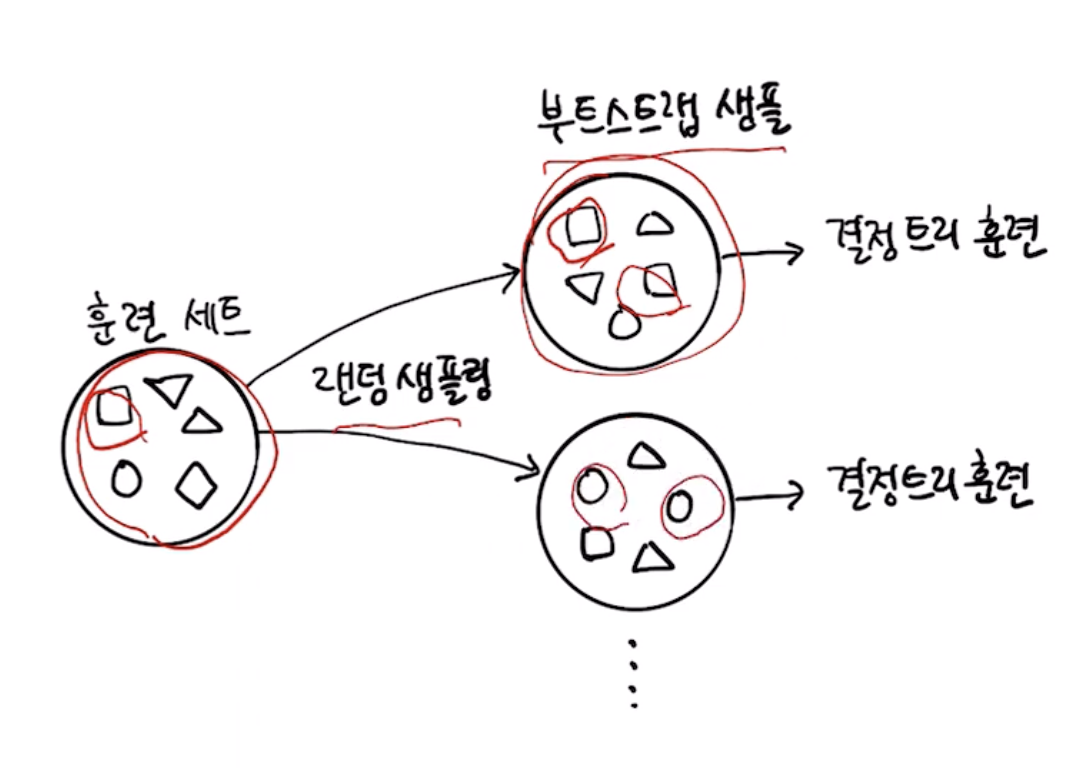


노드를 분할할때 전체 특성 중에서 일부 특성을 무작위로 고른 다음 이 중에서 최선의 분할을 찾음.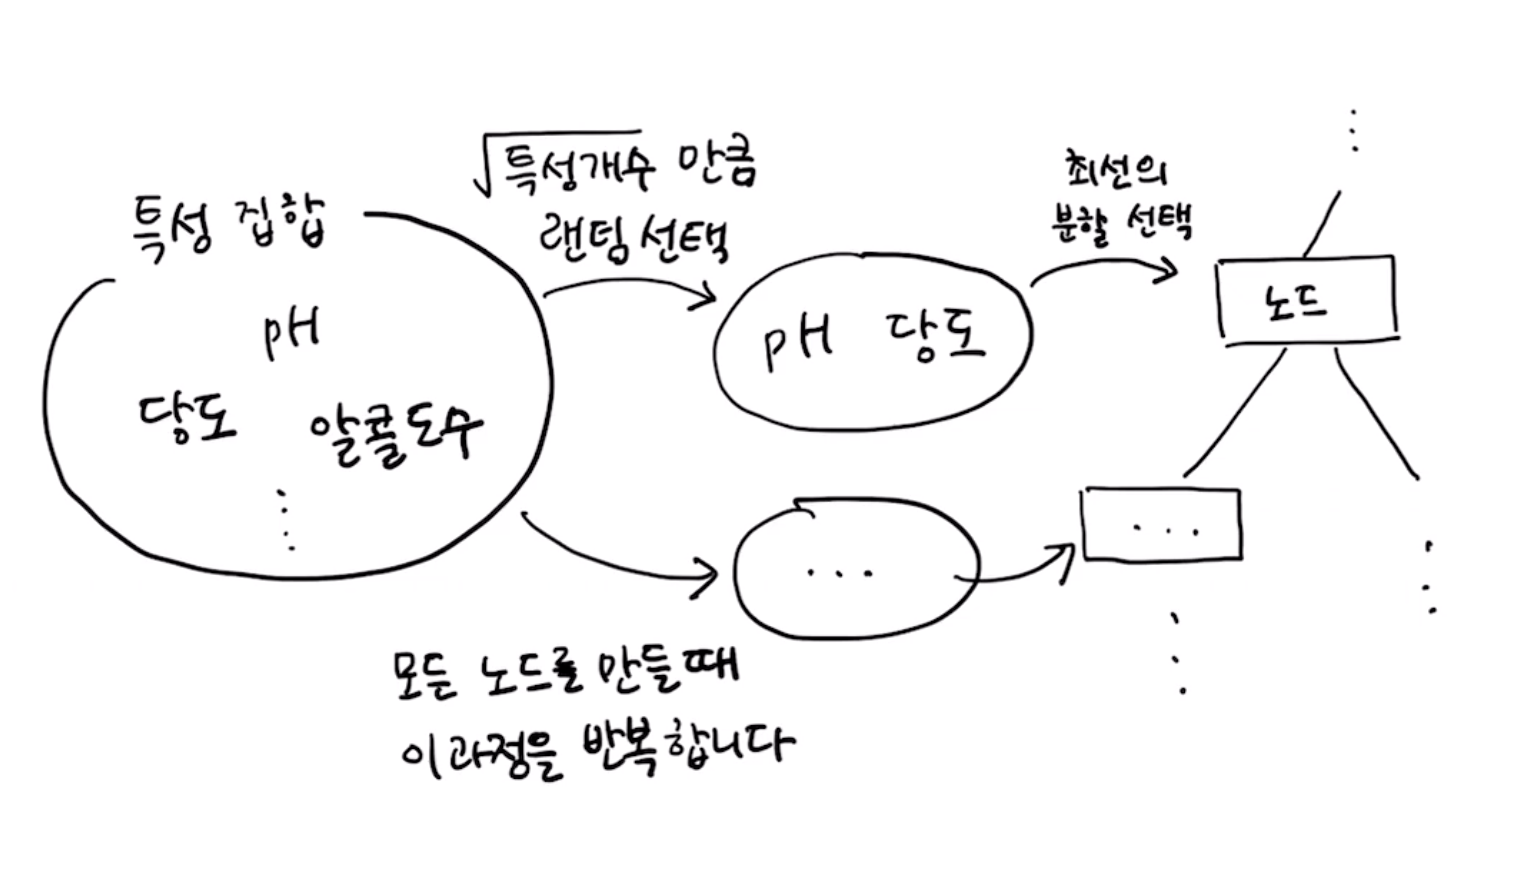

In [1]:
#데이터 가져오기
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

wine = pd.read_csv('https://bit.ly/wine_csv_data')
data = wine[['alcohol', 'sugar', 'pH']]
target = wine["class"]
train_input, test_input, train_target, test_target = train_test_split(data, target, random_state = 42, test_size = 0.2)

In [2]:
#교차검증 수행, 랜덤포레스트
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=-1, random_state=42)

#스코어 검증(return_train_score를 활성화할시 훈련 세트의 점수도 같이 반환되어 과대적합을 파악하는데 용이)
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs = -1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9973541965122431 0.8905151032797809


In [5]:
#랜덤 포레스트는 특성 중요도를 취합하여 나타내줌
rf.fit(train_input, train_target)
print(rf.feature_importances_)

[0.23167441 0.50039841 0.26792718]


In [7]:
#부트스트랩을 사용하면 사용되지 않는 샘플이 나오는데 이것을 사용해 검증세트처럼 사용할수 있다.
rf = RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=42)
rf.fit(train_input, train_target)
print(rf.oob_score_)

0.8934000384837406


## 엑스트라 트리
랜덤포레스트와 비슷하지만 부트스트랩 샘플이 아닌 전체 샘플을 사용

노드 분할도 랜덤

무작위로 분할한다면 성는ㅇ이 낮아지겠지만 많은 트리를 앙상블로 하기 때문에 과대적합을 막고 검증 세트의 점수를 높이는 효과가 있다.

In [8]:
#엑스트라 트리
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(n_jobs=-1, random_state=42)
scores = cross_validate(et, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9974503966084433 0.8887848893166506


In [9]:
#특성 중요도
et.fit(train_input, train_target)
print(et.feature_importances_)

[0.20183568 0.52242907 0.27573525]


## 그레이디언트 부스팅
깊이가 얕은 결정트리를 사용하여 이전 트리의 오차를 보완하는 방식으로 앙상블하는 방법

인기가 높은 앙상블 학습

In [10]:
#그레이디언트 부스팅(손실함수를 정하고 오차가 줄어드는 방향으로 트리 추가로 훈련)
from sklearn.ensemble import GradientBoostingClassifier

#손실함수를 찾아야하기에 병렬로 계산을 못함
gb = GradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.8881086892152563 0.8720430147331015


In [11]:
#과대적합에 강함.학습률 증가시켜보기(결정트리의 개수를 100개에서 500개로 늘려보기)
gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.2, random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))


0.9464595437171814 0.8780082549788999


In [12]:
gb.fit(train_input, train_target)
print(gb.feature_importances_)

[0.15887763 0.6799705  0.16115187]


## 히스토그램 기반 그레디언트 부스팅
정형 데이터를 다루는 머신러닝 알고리즘 중 가장 인기가 높은 알고리즘.

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(random_state=42)
scores = cross_validate(hgb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9321723946453317 0.8801241948619236


In [14]:
#특성 중요도를 제공하지 않음. 계산해야함
from sklearn.inspection import permutation_importance

hgb.fit(train_input, train_target)
result = permutation_importance(hgb, train_input, train_target, n_repeats=10, random_state=42, n_jobs=-1)
print(result.importances_mean)

[0.08876275 0.23438522 0.08027708]


In [15]:
#테스트 세트에서
result = permutation_importance(hgb, test_input, test_target, n_repeats=10, random_state=42, n_jobs=-1)
print(result.importances_mean)

[0.05969231 0.20238462 0.049     ]


In [16]:
#스코어 확인
hgb.score(test_input, test_target)

0.8723076923076923

## XGBoost vs LightGBM


In [17]:
#XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(tree_method = 'hist', random_state=42)
scores = cross_validate(xgb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9567059184812372 0.8783915747390243


In [18]:
#LightGBM
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(random_state=42)
scores = cross_validate(lgb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.935828414851749 0.8801251203079884


랜덤 포레스트는 가장 대표적인 앙상블 학습 알고리즘. 부트스트랩 샘플이 특징적

엑스트라 트리는 랜덤 포레스트와 비슷하지만 부트스트랩 샘프을 사용하지 않고 노드를 분할할때 최선이 아닌 랜덤 분할

그레이디언트 부스팅은 깊이가 얕은 트리를 연속적으로 추가하여 손실 함수를 최소화하는 앙상블 방법. 병렬로 훈련이 안되어서 속도가 조금 느림.

히스토그램 기반 그레이디언트 부스팅 알고리즘에는 훈련 데이터를 256개의 구간으로 변환하여 노드 분할 속도가 매우 빠름. 여기에는 XGBoost와 LightGBM이 있음.